In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
import pandas as pd
import numpy as np

##读取文件，若无法找到这个文件，则报错该文件无法找到
try:
    df = pd.read_csv("admin_2025-12-10 14-24-55_782BR20773.csv", skiprows=19, usecols=[2, 4, 5])
except FileNotFoundError:
    print("This File is not found.")

In [4]:
df1 = df[df['Target'] == 'Rp49'].copy()
df2 = df[df['Target'] == 'CG12896'].copy()
df3 = df[df['Target'] == 'CG31636'].copy()

In [5]:
df1_sorted = df1.sort_values(by='Sample')
df2_sorted = df2.sort_values(by='Sample')
df3_sorted = df3.sort_values(by='Sample')
df1_sorted

,Target,Sample,Cq
0,Rp49,DMSO#1,16.787647
24,Rp49,DMSO#1,16.899420
12,Rp49,DMSO#1,17.476339
1,Rp49,DMSO#2,17.888092
25,Rp49,DMSO#2,18.000294
13,Rp49,DMSO#2,17.695634
2,Rp49,DMSO#3,16.585147
26,Rp49,DMSO#3,16.589841
14,Rp49,DMSO#3,16.580687
3,Rp49,PFOA001#1,16.814847


In [6]:
Ser1 = df1_sorted['Cq']
Ser2 = df2_sorted['Cq']
Ser3 = df3_sorted['Cq'] 

print(type(Ser1[0]))
print(type(Ser1))

<class 'numpy.float64'>
<class 'pandas.core.series.Series'>


In [7]:
deltaCq1 = (Ser2.values - Ser1.values).tolist()
deltaCq2 = (Ser3.values - Ser1.values).tolist()
print(type(deltaCq1))
for i in deltaCq1:
    print(i)

<class 'list'>
4.035258141479503
4.395114438201798
4.319355033113602
3.420313887562898
3.650369518163501
3.6040589776802
4.895108303316601
4.6288616501833
4.471785131572599
4.250675873938299
4.9822190053534
4.0670966891627
2.7126854362729027
3.159581096914902
3.0183649361650993
3.652415964196699
2.541779013442099
3.742005748101601
3.376916765285902
2.954985797491098
3.255038404467399
3.6874197796256
3.068566430468497
3.285722111537101
4.9620442007005
4.893692115914
4.401152383729702


In [8]:
def two_neg_deltaCq(list1, list2):
    for _ in list1:
        _ = float(_)
        _ = 2 ** (-_)
        list2.append(_)

two_neg_deltaCq1 = []
two_neg_deltaCq2 = []
two_neg_deltaCq(deltaCq1, two_neg_deltaCq1)
two_neg_deltaCq(deltaCq2, two_neg_deltaCq2)

In [9]:
mean_2_neg_deltaCq1 = sum(two_neg_deltaCq1[:9])/len(two_neg_deltaCq1[:9])
mean_2_neg_deltaCq2 = sum(two_neg_deltaCq2[:9])/len(two_neg_deltaCq2[:9])

In [10]:
print(deltaCq1)

[4.035258141479503, 4.395114438201798, 4.319355033113602, 3.420313887562898, 3.650369518163501, 3.6040589776802, 4.895108303316601, 4.6288616501833, 4.471785131572599, 4.250675873938299, 4.9822190053534, 4.0670966891627, 2.7126854362729027, 3.159581096914902, 3.0183649361650993, 3.652415964196699, 2.541779013442099, 3.742005748101601, 3.376916765285902, 2.954985797491098, 3.255038404467399, 3.6874197796256, 3.068566430468497, 3.285722111537101, 4.9620442007005, 4.893692115914, 4.401152383729702]


In [11]:
def Nor_2_neg_deltaCq(list1, list2, mean):
    for _ in list1:
        _ = _ / mean
        list2.append(_)

Nor_2_neg_deltaCq1 = []
Nor_2_neg_deltaCq2 = []
Nor_2_neg_deltaCq(two_neg_deltaCq1, Nor_2_neg_deltaCq1, mean_2_neg_deltaCq1)
Nor_2_neg_deltaCq(two_neg_deltaCq2, Nor_2_neg_deltaCq2, mean_2_neg_deltaCq2)

In [12]:
groups = ['DMSO', 'PFOA 0.01mg/L', 'PFOA 1mg/L']
final_df1 = pd.DataFrame({
    'Group': np.repeat(groups, 9),
    'Value': Nor_2_neg_deltaCq1
})
final_df2 = pd.DataFrame({
    'Group': np.repeat(groups, 9),
    'Value': Nor_2_neg_deltaCq2
})

In [14]:
final_df1.to_csv(f'{df2['Target'].iloc[0]}_qPCR_result.csv')
final_df2.to_csv(f'{df3['Target'].iloc[0]}_qPCR_result.csv')

In [15]:
group_DMSO = final_df1[final_df1['Group'] == 'DMSO']['Value']
group_PFOA_001 = final_df1[final_df1['Group'] == 'PFOA 0.01mg/L']['Value']
group_PFOA_1 = final_df1[final_df1['Group'] == 'PFOA 1mg/L']['Value']

In [17]:
_, p_val_001 = stats.ttest_ind(group_DMSO, group_PFOA_001)
_, p_val_1 = stats.ttest_ind(group_DMSO, group_PFOA_1)

In [18]:
def pvalue2asterisks(pvalue):
    if pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    else:
        return "ns"

In [19]:
plt.figure(figsize=(8, 6))
sns.set_style("ticks")

<Figure size 800x600 with 0 Axes>

C:\Users\ChangeJam\AppData\Local\Temp\ipykernel_11308\2982015826.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  ax = sns.barplot(x='Group', y='Value', data=final_df1,
C:\Users\ChangeJam\AppData\Local\Temp\ipykernel_11308\2982015826.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Group', y='Value', data=final_df1,
C:\Users\ChangeJam\AppData\Local\Temp\ipykernel_11308\2982015826.py:3: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(x='Group', y='Value', data=final_df1,


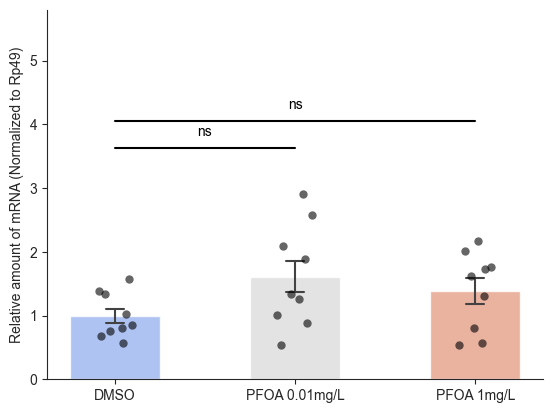

In [ ]:
ax = sns.barplot(x='Group', y='Value', data=final_df1, 
                 palette='coolwarm', 
                 width=0.5,
                 capsize=0.1,   # 添加误差线顶端的横杠
                 errwidth=1.5,  # 误差线宽度
                 ci=68,         # 68% CI ≈ SEM; 设为 'sd' 则为标准差
                 alpha=0.8)     # 条形透明度

sns.stripplot(x='Group', y='Value', data=final_df1,
              color='black',
              alpha=0.6,
              size=6,
              jitter=True,
              ax=ax)

y_max = final_df1['Value'].max()
h = y_max * 0.05

x1, x2 = 0, 1
plt.plot([x1, x2],
         [y_max + 5*h, y_max + 5*h],
         lw=1.5, c='k')

plt.text((x1+x2)*.5, y_max + 6*h, pvalue2asterisks(p_val_001),
         ha='center', va='bottom', color='k')

x1, x2 = 0, 2
# 注意高度要比前一个更高，避免重叠
plt.plot([x1, x2], 
         [y_max + 8*h, y_max + 8*h], 
         lw=1.5, c='k')
plt.text((x1+x2)*.5, y_max + 9*h, pvalue2asterisks(p_val_1), 
         ha='center', va='bottom', color='k')

plt.xlabel('')
plt.ylabel('Relative amount of mRNA (Normalized to Rp49)')

plt.ylim(0, y_max * 2)

sns.despine()

plt.show()